# **Analisis Naive Bayes Menggunakan Data Customer Churn E-Commerce**

## **1. IMPORT LIBRARY**

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt

## **2. UPLOAD DATA**

In [3]:
from google.colab import files
uploaded = files.upload()
df = pd.read_csv("data_ecommerce_customer_churn.csv")
# Lihat data
df.head()

Saving data_ecommerce_customer_churn.csv to data_ecommerce_customer_churn (1).csv


,Tenure,WarehouseToHome,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn
0,15.0,29.0,4,Laptop & Accessory,3,Single,2,0,7.0,143.32,0
1,7.0,25.0,4,Mobile,1,Married,2,0,7.0,129.29,0
2,27.0,13.0,3,Laptop & Accessory,1,Married,5,0,7.0,168.54,0
3,20.0,25.0,4,Fashion,3,Divorced,7,0,NaN,230.27,0
4,30.0,15.0,4,Others,4,Single,8,0,8.0,322.17,0


##**3. CEK DATA**

In [4]:
print(df.shape)
print(df.info())
print(df.isnull().sum())

(3941, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3941 entries, 0 to 3940
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Tenure                    3747 non-null   float64
 1   WarehouseToHome           3772 non-null   float64
 2   NumberOfDeviceRegistered  3941 non-null   int64  
 3   PreferedOrderCat          3941 non-null   object 
 4   SatisfactionScore         3941 non-null   int64  
 5   MaritalStatus             3941 non-null   object 
 6   NumberOfAddress           3941 non-null   int64  
 7   Complain                  3941 non-null   int64  
 8   DaySinceLastOrder         3728 non-null   float64
 9   CashbackAmount            3941 non-null   float64
 10  Churn                     3941 non-null   int64  
dtypes: float64(4), int64(5), object(2)
memory usage: 338.8+ KB
None
Tenure                      194
WarehouseToHome             169
NumberOfDeviceRegistered      0
Pr

## **4. HANDLE MISSING VALUE**

In [5]:
# Isi numerik dengan median
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Cek ulang missing value
print(df.isnull().sum())

Tenure                      0
WarehouseToHome             0
NumberOfDeviceRegistered    0
PreferedOrderCat            0
SatisfactionScore           0
MaritalStatus               0
NumberOfAddress             0
Complain                    0
DaySinceLastOrder           0
CashbackAmount              0
Churn                       0
dtype: int64


/tmp/ipykernel_4140/1519959713.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


## **5. ENCODING DATA KATEGORIK**

In [6]:
le = LabelEncoder()

cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

df.head()

,Tenure,WarehouseToHome,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn
0,15.0,29.0,4,2,3,2,2,0,7.0,143.32,0
1,7.0,25.0,4,3,1,1,2,0,7.0,129.29,0
2,27.0,13.0,3,2,1,1,5,0,7.0,168.54,0
3,20.0,25.0,4,0,3,0,7,0,3.0,230.27,0
4,30.0,15.0,4,5,4,2,8,0,8.0,322.17,0


## **6. SPLIT DATA**

In [7]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(3152, 10)
(789, 10)


## **7. MODEL NAIVE BAYES**

In [8]:
model = GaussianNB()
model.fit(X_train, y_train)

# Prediksi
y_pred = model.predict(X_test)

## **8. EVALUASI MODEL**


In [9]:
acc = accuracy_score(y_test, y_pred)
print("Akurasi :", round(acc*100,2), "%")

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Akurasi : 85.8 %

Classification Report
              precision    recall  f1-score   support

           0       0.92      0.91      0.91       654
           1       0.58      0.59      0.59       135

    accuracy                           0.86       789
   macro avg       0.75      0.75      0.75       789
weighted avg       0.86      0.86      0.86       789



Berdasarkan hasil analisis menggunakan metode Naive Bayes, diperoleh nilai akurasi sebesar 85,8%. Artinya, model mampu memprediksi status pelanggan churn dan tidak churn dengan benar sebesar 85,8% dari total 789 data uji. Secara umum, nilai ini menunjukkan performa model yang cukup baik.

**1.Interpretasi Kelas 0 (Tidak Churn)**

Untuk kelas 0 (pelanggan tidak churn) diperoleh:

Precision = 0,92

Artinya, dari seluruh pelanggan yang diprediksi tidak churn, sebanyak 92% benar-benar tidak churn.

Recall = 0,91

Artinya, dari seluruh pelanggan yang benar-benar tidak churn, model berhasil mendeteksi 91%.

F1-score = 0,91

Menunjukkan keseimbangan precision dan recall yang sangat baik pada kelas tidak churn.

Kesimpulan: Model sangat baik dalam mengenali pelanggan yang tetap bertahan.

**2.Interpretasi Kelas 1 (Churn)**

Untuk kelas 1 (pelanggan churn) diperoleh:

Precision = 0,58

Artinya, dari seluruh pelanggan yang diprediksi churn, hanya 58% yang benar-benar churn.

Recall = 0,59

Artinya, dari seluruh pelanggan yang benar-benar churn, model hanya mampu mendeteksi 59%.

F1-score = 0,59

Menunjukkan performa model dalam mendeteksi churn masih sedang.

Kesimpulan: Model masih kurang optimal dalam mendeteksi pelanggan yang berpotensi churn.

**3. Macro Average**

Precision = 0,75

Recall = 0,75

F1-score = 0,75

Rata-rata performa antar kelas adalah 75%, yang berarti kemampuan model secara keseluruhan cukup baik namun belum merata antara kelas churn dan tidak churn.

**4.Weighted Average**

Precision = 0,86

Recall = 0,86

F1-score = 0,86

Nilai weighted average tinggi karena jumlah data kelas 0 lebih banyak dibanding kelas 1, sehingga performa kelas mayoritas lebih dominan.

**Kesimpulan Akhir**

Model Naive Bayes memiliki performa baik dengan akurasi tinggi (85,8%), terutama dalam memprediksi pelanggan tidak churn. Namun, kemampuan model dalam mendeteksi pelanggan churn masih perlu ditingkatkan karena precision dan recall kelas churn masih rendah. Untuk meningkatkan hasil, dapat digunakan teknik seperti SMOTE, tuning model, atau algoritma lain seperti Random Forest dan XGBoost.

## **9. CONFUSION MATRIX**

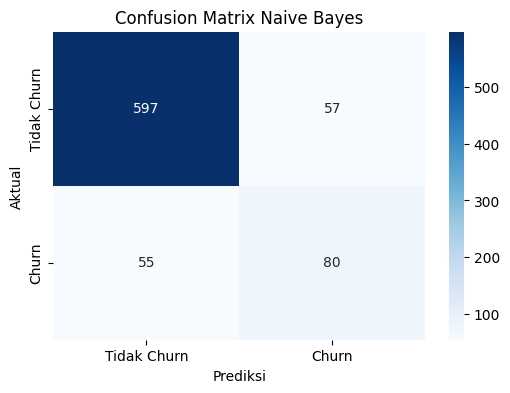

In [10]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Tidak Churn','Churn'],
            yticklabels=['Tidak Churn','Churn'])
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.title("Confusion Matrix Naive Bayes")
plt.show()

**1.True Negative (TN) = 597**

Sebanyak 597 pelanggan yang sebenarnya tidak churn berhasil diprediksi tidak churn oleh model.

Artinya, model sangat baik dalam mengenali pelanggan yang tetap bertahan.

**2.False Positive (FP) = 57**

Sebanyak 57 pelanggan yang sebenarnya tidak churn, tetapi diprediksi churn.

Artinya, model mengira pelanggan akan keluar padahal sebenarnya tetap bertahan.

**3.False Negative (FN) = 55**

Sebanyak 55 pelanggan yang sebenarnya churn, tetapi diprediksi tidak churn.

Ini cukup penting karena pelanggan yang seharusnya perlu dipertahankan justru tidak terdeteksi.

**4.True Positive (TP) = 80**

Sebanyak 80 pelanggan yang benar-benar churn berhasil diprediksi churn oleh model.

Artinya, model mampu mendeteksi sebagian pelanggan yang berpotensi keluar.

**Kesimpulan**

Secara keseluruhan, model memiliki performa yang baik karena mampu mengklasifikasikan mayoritas pelanggan dengan benar, terutama pada kelas tidak churn. Namun, masih terdapat kesalahan prediksi pada pelanggan churn (55 kasus) dan pelanggan tidak churn (57 kasus). Hal ini menunjukkan bahwa model lebih kuat dalam mengenali pelanggan yang bertahan dibandingkan mendeteksi pelanggan yang akan churn.

Untuk keperluan bisnis, kesalahan false negative perlu diperhatikan karena perusahaan bisa kehilangan pelanggan tanpa tindakan pencegahan.

## **10. PREDIKSI DATA BARU**

In [11]:
hasil = pd.DataFrame({
    'Aktual': y_test,
    'Prediksi': y_pred
})

hasil.head(10)

,Aktual,Prediksi
1293,0,0
1635,0,0
483,0,0
2571,0,0
3376,0,0
1352,0,0
2881,0,0
2931,0,0
2123,0,0
2886,0,0


Pada 10 data yang ditampilkan, seluruh pelanggan memiliki status aktual tidak churn (0) dan semuanya berhasil diprediksi tidak churn (0) oleh model.

Artinya, untuk sampel data ini model bekerja dengan tepat 100% karena tidak ada kesalahan prediksi pada baris yang ditampilkan.

**Kesimpulan**

Model Naive Bayes menunjukkan kemampuan yang baik dalam mengenali pelanggan yang tidak churn. Hal ini sejalan dengan hasil evaluasi sebelumnya bahwa performa model lebih kuat pada kelas tidak churn dibandingkan kelas churn.